In [1]:
from load_op_inputs import load_op_input_and_fluid

# One function call for all requested OPs
all_data = load_op_input_and_fluid([1])

print("Input headers:", all_data[1]["input_headers"])
print("Input signals array:\n", all_data[1]["input_signals"])
print("Fluid headers:", all_data[1]["fluid_headers"])
print("Fluidstoffwerte array:\n", all_data[1]["fluidstoffwerte"])

Input headers: ['C-Rate Monitor (1/h)', 'Cell Current Monitor (A)', 'Fluid Initial Temperature Monitor (C)', 'Fluid Inlet Temperature Monitor (C)', 'Fluid Mass Flow Monitor (kg/s)', 'SOC Start Monitor (%)', 'Solid Initial Temperature Monitor (C)']
Input signals array:
 [[2.00e+00 3.16e+02 2.50e+01 2.50e+01 1.30e-03 1.00e+01 2.50e+01]]
Fluid headers: ['Conductivity Monitor (W/m-K)', 'Density Monitor (kg/m^3)', 'Specific Inlet Monitor (J/kg-K)']
Fluidstoffwerte array:
 [[4.00127323e-01 1.07163576e+03 3.37408560e+03]]


epoch 120/600, train_loss=0.001298
epoch 240/600, train_loss=0.001072
epoch 360/600, train_loss=0.000849
epoch 480/600, train_loss=0.000626
epoch 600/600, train_loss=0.000453
Backend: torch
Test RMSE bc_SOC: 3.045844
Test RMSE bc_Q: 20473.548828
Saved plot to: /mnt/c/Users/M0245635/batterysurrogatemodell/outputs/op_surrogate_compare.png
Saved debug arrays to: /mnt/c/Users/M0245635/batterysurrogatemodell/outputs/op_surrogate_debug.npz

/mnt/c/Users/M0245635/batterysurrogatemodell/physics_env_fixed/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return to

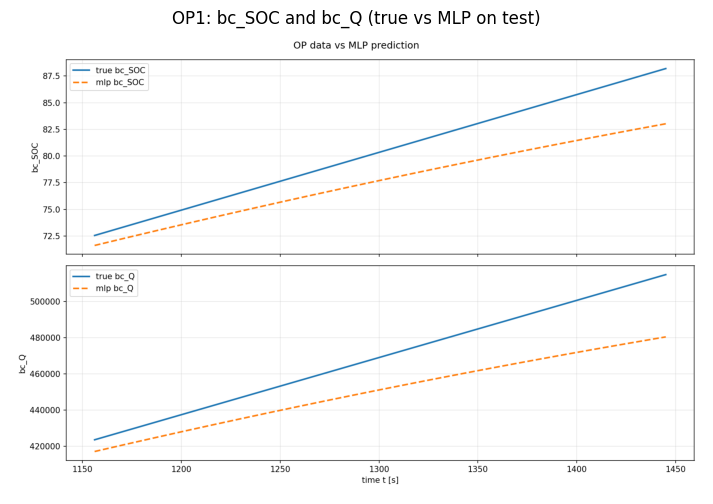

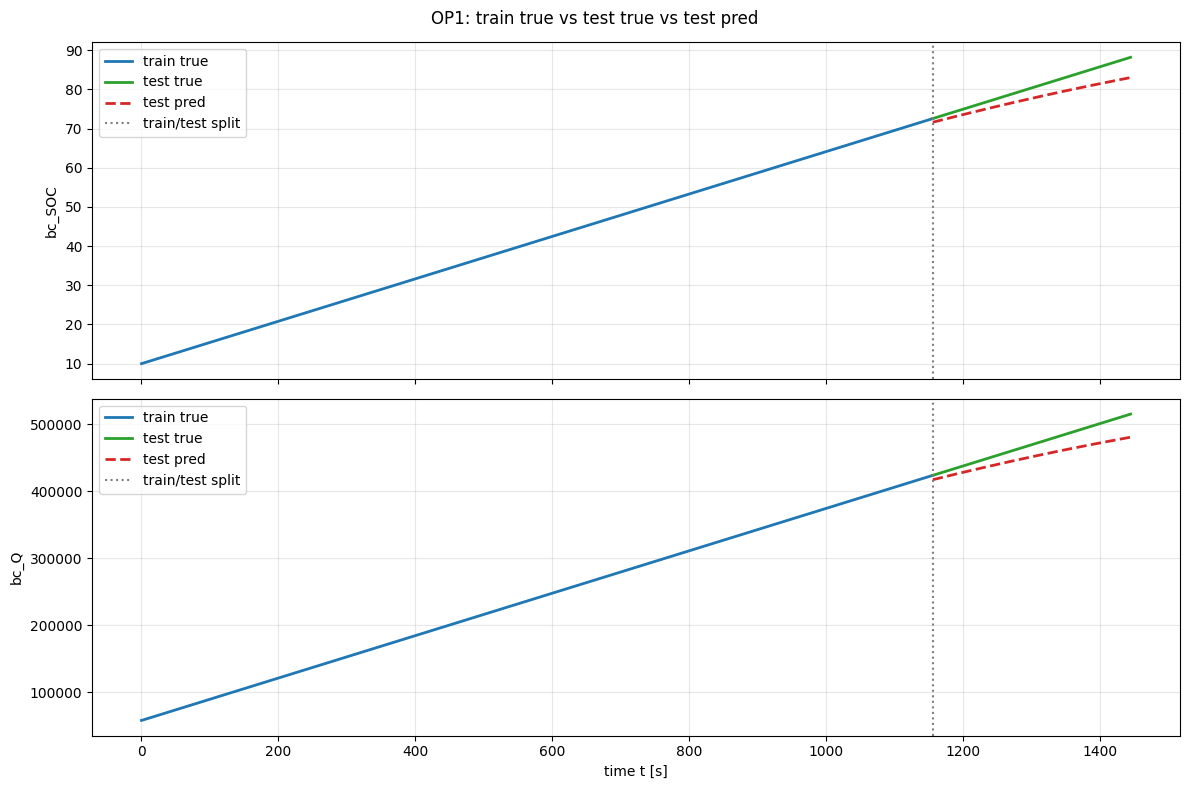

In [8]:
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# OP selection in main notebook (default OP1).
op_id = 1

# Existing environment and script in this workspace.
ws_root = Path(r"c:\Users\M0245635\batterysurrogatemodell")
script_path_wsl = "/mnt/c/Users/M0245635/batterysurrogatemodell/op_surrogate_mlp.py"
python_wsl = "/mnt/c/Users/M0245635/batterysurrogatemodell/physics_env_fixed/bin/python"
dataset_root_wsl = "/mnt/c/Users/M0245635/Downloads"
plot_path_wsl = "/mnt/c/Users/M0245635/batterysurrogatemodell/outputs/op_surrogate_compare.png"
debug_path_wsl = "/mnt/c/Users/M0245635/batterysurrogatemodell/outputs/op_surrogate_debug.npz"
plot_path_win = ws_root / "outputs" / "op_surrogate_compare.png"
debug_path_win = ws_root / "outputs" / "op_surrogate_debug.npz"

cmd = [
    "wsl",
    python_wsl,
    script_path_wsl,
    "--op-id", str(op_id),
    "--dataset-root", dataset_root_wsl,
    "--epochs", "600",
    "--train-ratio", "0.8",
    "--lr", "1e-3",
    "--no-show",
    "--plot-path", plot_path_wsl,
    "--dump-path", debug_path_wsl,
]

completed = subprocess.run(cmd, capture_output=True, text=True, check=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)

# Figure 1: existing test true vs prediction image from script.
img = mpimg.imread(plot_path_win)
plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"OP{op_id}: bc_SOC and bc_Q (true vs MLP on test)")
plt.show()

# Figure 2: explicit train true + test true + test prediction.
debug = np.load(debug_path_win, allow_pickle=True)
t_train = debug["t_train"][:, 0]
y_train = debug["y_train"]
t_test = debug["t_test"][:, 0]
y_test = debug["y_test"]
y_pred_test = debug["y_pred_test"]
target_names = [str(x) for x in debug["target_names"]]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(t_train, y_train[:, i], color="tab:blue", linewidth=2, label="train true")
    ax.plot(t_test, y_test[:, i], color="tab:green", linewidth=2, label="test true")
    ax.plot(t_test, y_pred_test[:, i], "--", color="tab:red", linewidth=2, label="test pred")
    ax.axvline(t_train[-1], color="gray", linestyle=":", linewidth=1.5, label="train/test split")
    ax.set_ylabel(target_names[i])
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("time t [s]")
fig.suptitle(f"OP{op_id}: train true vs test true vs test pred")
fig.tight_layout()
plt.show()